AMAZON MOVIES & TV ANALYSIS (USING MRJOB LIBRARY WITH SAMPLE REVIEWS)

In [1]:
%pip install mrjob textblob matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
from collections import Counter, defaultdict
from textblob import TextBlob
import matplotlib.pyplot as plt
import time
import pandas as pd
import os
import subprocess

In [4]:
with open("Movies_and_TV.jsonl", "r", encoding="utf-8") as f:
    first_review = json.loads(f.readline())
    
print("COMPLETE FIRST REVIEW - ALL FIELDS:")
for key, value in first_review.items():
    print(f"{key:20}: {type(value).__name__} = {value}")
print(f"\nTotal fields: {len(first_review.keys())}")

COMPLETE FIRST REVIEW - ALL FIELDS:
rating              : float = 5.0
title               : str = Five Stars
text                : str = Amazon, please buy the show! I'm hooked!
images              : list = []
asin                : str = B013488XFS
parent_asin         : str = B013488XFS
user_id             : str = AGGZ357AO26RQZVRLGU4D4N52DZQ
timestamp           : int = 1440385637000
helpful_vote        : int = 0
verified_purchase   : bool = True

Total fields: 10


In [5]:
# Load product metadata (uses parent_asin which matches review parent_asin)
product_names = {}

print("Loading product metadata from meta_Movies_and_TV.jsonl...")
with open("meta_Movies_and_TV.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i % 500000 == 0:
            print(f"  Loaded {i:,} products...")
        meta = json.loads(line)
        
        parent_asin = meta.get('parent_asin', '')
        title = meta.get('title', '')
        
        if parent_asin and title:
            product_names[parent_asin] = title

print(f"\n Loaded metadata for {len(product_names):,} products")

Loading product metadata from meta_Movies_and_TV.jsonl...
  Loaded 0 products...
  Loaded 500,000 products...

 Loaded metadata for 434,222 products


In [6]:
# Write mrjob script for Task 2
task2_script = """
from mrjob.job import MRJob
import json

class ReviewCount(MRJob):
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            yield review['parent_asin'], 1
        except:
            pass
    
    def reducer(self, product_id, counts):
        yield product_id, sum(counts)

if __name__ == '__main__':
    ReviewCount.run()
"""

with open("task2_review_count.py", "w") as f:
    f.write(task2_script)

print(" Created task2_review_count.py")

 Created task2_review_count.py


In [9]:
print("TASK 2: RUNNING MRJOB ON FULL DATASET")

# Run mrjob on full dataset
!python task2_review_count.py Movies_and_TV.jsonl --output-dir=output_task2 --no-conf

print("\n Task 2 completed!")

TASK 2: RUNNING MRJOB ON FULL DATASET

 Task 2 completed!


No configs specified for inline runner
Running step 1 of 1...
Creating temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task2_review_count.Administrator.20260601.074713.602301
job output is in output_task2
Removing temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task2_review_count.Administrator.20260601.074713.602301...


In [10]:
# Load results from mrjob output
task2_results = {}

output_file = "output_task2/part-00000"
if os.path.exists(output_file):
    with open(output_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                product_id = parts[0].strip('"')
                count = int(parts[1])
                task2_results[product_id] = count

print("TASK 2: COUNT REVIEWS PER PRODUCT - FINAL RESULTS")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<50} {'Review Count':<12}")

# Sort by count
sorted_results = sorted(task2_results.items(), key=lambda x: x[1], reverse=True)

for rank, (asin, count) in enumerate(sorted_results[:30], 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    name_str = str(name)[:50]
    print(f"{rank:<6} {asin:<20} {name_str:<50} {count:>10,}")

print(f"\n... and {len(sorted_results) - 30:,} more products")
print(f"\n Total unique products: {len(task2_results):,}")
print(f" Total reviews processed: {sum(task2_results.values()):,}")

TASK 2: COUNT REVIEWS PER PRODUCT - FINAL RESULTS
Rank   Product ID           Product Name                                       Review Count
1      B0000AQS0F           Firefly: The Complete Series                            3,942
2      6305428042           Buena Vista Home Video, Hocus Pocus                     2,227
3      6304711905           Tombstone                                               1,860
4      B00003CXRM           O Brother, Where Art Thou?                              1,563
5      B00005JLEU           Spirited Away                                           1,550
6      B00005JKTY           Schoolhouse Rock! (Special 30th Anniversary Editio      1,543
7      B00003CXCT           Star Wars Trilogy (A New Hope / The Empire Strikes      1,483
8      B00006CXSS           Band of Brothers                                        1,399
9      B00004W46I           Somewhere in Time (Collector's Edition)                 1,361
10     B00005JNBQ           Napoleon Dynamite   

In [11]:
# Write mrjob script for Task 3
task3_script = """
from mrjob.job import MRJob
import json

class AvgRating(MRJob):
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            yield review['parent_asin'], (review['rating'], 1)
        except:
            pass
    
    def reducer(self, product_id, values):
        total_rating = 0
        total_count = 0
        for rating, count in values:
            total_rating += rating
            total_count += count
        yield product_id, total_rating / total_count

if __name__ == '__main__':
    AvgRating.run()
"""

with open("task3_avg_rating.py", "w") as f:
    f.write(task3_script)

print(" Created task3_avg_rating.py")

 Created task3_avg_rating.py


In [12]:
print("TASK 3: RUNNING MRJOB ON FULL DATASET")


!python task3_avg_rating.py Movies_and_TV.jsonl --output-dir=output_task3 --no-conf

print("\n Task 3 completed!")

TASK 3: RUNNING MRJOB ON FULL DATASET

 Task 3 completed!


No configs specified for inline runner
Running step 1 of 1...
Creating temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task3_avg_rating.Administrator.20260601.075914.736343
job output is in output_task3
Removing temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task3_avg_rating.Administrator.20260601.075914.736343...


In [13]:
# Load results from mrjob output
task3_results = {}

output_file = "output_task3/part-00000"
if os.path.exists(output_file):
    with open(output_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                product_id = parts[0].strip('"')
                avg_rating = float(parts[1])
                task3_results[product_id] = avg_rating

print("TASK 3: AVERAGE STAR RATING PER PRODUCT")


# Filter products with at least 100 reviews
filtered_results = [(asin, avg, task2_results.get(asin, 0)) 
                    for asin, avg in task3_results.items() 
                    if task2_results.get(asin, 0) >= 100]
filtered_results.sort(key=lambda x: x[1], reverse=True)

print(f"\nTop 20 Highest Rated Products (minimum 100 reviews):")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<50} {'Avg Rating':<12} {'Reviews':<10}")

for rank, (asin, avg, count) in enumerate(filtered_results[:20], 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    name_str = str(name)[:50]
    print(f"{rank:<6} {asin:<20} {name_str:<50} {avg:<12.2f} {count:<10,}")

# Global average
all_ratings_avg = sum(task3_results.values()) / len(task3_results)
print(f"\n Global average rating across all products: {all_ratings_avg:.3f} stars")

TASK 3: AVERAGE STAR RATING PER PRODUCT

Top 20 Highest Rated Products (minimum 100 reviews):
Rank   Product ID           Product Name                                       Avg Rating   Reviews   
1      B00005JO9K           Cold Case                                          4.98         118       
2      B00005JNS4           Ed: Season 1                                       4.96         156       
3      B00006JDQF           Raffi in Concert                                   4.94         127       
4      B0000296R6           Strangers in Good Company                          4.93         103       
5      B000056HEH           Lilies of the Field [DVD]                          4.92         103       
6      B00009XN37           Yes, Prime Minister: The Complete Collection (DVD) 4.92         119       
7      B00006FDCP           One Flew over the Cuckoo's Nest (Two-Disc Special  4.91         105       
8      B00008978P           Stella                                             4.9

In [14]:
# Write mrjob script for Task 4
task4_script = """
from mrjob.job import MRJob
from mrjob.step import MRStep
import json

class TopTenProducts(MRJob):
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            yield review['parent_asin'], 1
        except:
            pass
    
    def reducer_count(self, product_id, counts):
        yield None, (sum(counts), product_id)
    
    def reducer_top10(self, _, product_counts):
        for count, product_id in sorted(product_counts, reverse=True)[:10]:
            yield product_id, count
    
    def steps(self):
        return [
            MRStep(mapper=self.mapper, reducer=self.reducer_count),
            MRStep(reducer=self.reducer_top10)
        ]

if __name__ == '__main__':
    TopTenProducts.run()
"""

with open("task4_top10.py", "w") as f:
    f.write(task4_script)

print(" Created task4_top10.py")

 Created task4_top10.py


In [15]:
print("TASK 4: RUNNING MRJOB ON FULL DATASET")

!python task4_top10.py Movies_and_TV.jsonl --output-dir=output_task4 --no-conf

print("\n Task 4 completed!")

TASK 4: RUNNING MRJOB ON FULL DATASET

 Task 4 completed!


No configs specified for inline runner
Running step 1 of 2...
Creating temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task4_top10.Administrator.20260601.081203.380594
Running step 2 of 2...
job output is in output_task4
Removing temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task4_top10.Administrator.20260601.081203.380594...


In [16]:
# Load results from mrjob output
task4_results = []

output_file = "output_task4/part-00000"
if os.path.exists(output_file):
    with open(output_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                product_id = parts[0].strip('"')
                count = int(parts[1])
                task4_results.append((product_id, count))

print("TASK 4: TOP TEN MOST REVIEWED PRODUCTS")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<60} {'Review Count':<12}")

for rank, (asin, count) in enumerate(task4_results, 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    print(f"{rank:<6} {asin:<20} {str(name)[:60]:<60} {count:>10,}")

TASK 4: TOP TEN MOST REVIEWED PRODUCTS
Rank   Product ID           Product Name                                                 Review Count
1      B00RSGIVVO           NAME NOT FOUND                                                   62,445
2      B00I3MQNWG           NAME NOT FOUND                                                   56,532
3      B01J4SRJFW           NAME NOT FOUND                                                   48,333
4      B01AB17IGQ           NAME NOT FOUND                                                   28,998
5      B01J94A5GQ           NAME NOT FOUND                                                   27,607
6      B007SPQZMC           NAME NOT FOUND                                                   25,681
7      B00X8UKOUK           NAME NOT FOUND                                                   24,359
8      B00MR9UY8A           NAME NOT FOUND                                                   23,898
9      B003AZCYCE           NAME NOT FOUND                 

In [17]:
# Write mrjob script for Task 5
task5_script = """
from mrjob.job import MRJob
import json

class HelpfulnessScore(MRJob):
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            asin = review['parent_asin']
            helpful = review.get('helpful_vote', 0)
            
            # Emit: helpful if >0, unhelpful if 0
            if helpful > 0:
                yield asin, ('helpful', helpful)
            else:
                yield asin, ('unhelpful', 1)
        except:
            pass
    
    def reducer(self, asin, values):
        helpful_total = 0
        unhelpful_total = 0
        
        for value_type, value in values:
            if value_type == 'helpful':
                helpful_total += value
            else:
                unhelpful_total += 1
        
        total_votes = helpful_total + unhelpful_total
        if total_votes > 0:
            score = helpful_total / total_votes
        else:
            score = 0
        
        yield asin, score

if __name__ == '__main__':
    HelpfulnessScore.run()
"""

with open("task5_helpfulness.py", "w") as f:
    f.write(task5_script)

print("Created task5_helpfulness.py")

Created task5_helpfulness.py


In [18]:
print("TASK 5: RUNNING MRJOB ON FULL DATASET")

!python task5_helpfulness.py Movies_and_TV.jsonl --output-dir=output_task5 --no-conf

print("\n Task 5 completed!")

TASK 5: RUNNING MRJOB ON FULL DATASET

 Task 5 completed!


No configs specified for inline runner
Running step 1 of 1...
Creating temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task5_helpfulness.Administrator.20260601.082409.029926
job output is in output_task5
Removing temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task5_helpfulness.Administrator.20260601.082409.029926...


In [19]:
# Load results from mrjob output
task5_results = {}

output_file = "output_task5/part-00000"
if os.path.exists(output_file):
    with open(output_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                product_id = parts[0].strip('"')
                score = float(parts[1])
                task5_results[product_id] = score

print("TASK 5: AVERAGE HELPFULNESS SCORE ")
print("FORMULA: helpfulness_score = total_helpful_votes / (helpful_votes + unhelpful_votes)")
print("Range: 0 to 1 (1 = all votes were helpful)")


# Filter products with at least 100 reviews
helpful_products = [(asin, task5_results[asin], task2_results.get(asin, 0)) 
                    for asin in task5_results if task2_results.get(asin, 0) >= 100]
helpful_products.sort(key=lambda x: x[1], reverse=True)

# Calculate average across all products
avg_helpfulness = sum(task5_results.values()) / len(task5_results)
print(f"\n Average Helpfulness Score across all products: {avg_helpfulness:.6f}")

print(f"\n TOP 20 MOST HELPFUL PRODUCTS (minimum 100 reviews):")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<50} {'Score':<10} {'Reviews':<10}")

for rank, (asin, score, reviews) in enumerate(helpful_products[:20], 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    name_str = str(name)[:50]
    print(f"{rank:<6} {asin:<20} {name_str:<50} {score:<10.4f} {reviews:<10,}")

# Least helpful
least_helpful = sorted(helpful_products, key=lambda x: x[1])[:10]
print(f"\n LEAST HELPFUL PRODUCTS (minimum 100 reviews):")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<50} {'Score':<10} {'Reviews':<10}")


for rank, (asin, score, reviews) in enumerate(least_helpful, 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    name_str = str(name)[:50]
    print(f"{rank:<6} {asin:<20} {name_str:<50} {score:<10.4f} {reviews:<10,}")

TASK 5: AVERAGE HELPFULNESS SCORE 
FORMULA: helpfulness_score = total_helpful_votes / (helpful_votes + unhelpful_votes)
Range: 0 to 1 (1 = all votes were helpful)

 Average Helpfulness Score across all products: 0.668711

 TOP 20 MOST HELPFUL PRODUCTS (minimum 100 reviews):
Rank   Product ID           Product Name                                       Score      Reviews   
1      B00005JNEI           Fahrenheit 9/11                                    0.9985     676       
2      B00005JO9K           Cold Case                                          0.9913     118       
3      B000069YWP           Classical Pilates Technique: The Complete Mat Work 0.9906     237       
4      B00005JPY0           The Dark Knight                                    0.9903     139       
5      B00005JMSD           China Beach: The Complete Series                   0.9898     143       
6      B00005JOSA           The Christmas List                                 0.9897     138       
7      B00005JNF7 

In [30]:
# Write working mrjob script for Task 6
task6_script = """
from mrjob.job import MRJob
from textblob import TextBlob
import json
import random

class SentimentAnalysis(MRJob):
    
    def get_sentiment_with_details(self, text):
        if not text or len(text.strip()) < 5:
            return 'neutral', 0.0, 0.0, ''
        try:
            blob = TextBlob(text[:1000])
            polarity = blob.sentiment.polarity
            subjectivity = blob.sentiment.subjectivity
            
            if polarity > 0.1:
                return 'positive', polarity, subjectivity, text[:400]
            elif polarity < -0.1:
                return 'negative', polarity, subjectivity, text[:400]
            else:
                return 'neutral', polarity, subjectivity, text[:400]
        except:
            return 'neutral', 0.0, 0.0, text[:400] if text else ''
    
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            text = review.get('text', '')
            rating = review.get('rating', 0)
            asin = review.get('parent_asin', '')
            
            sentiment, polarity, subjectivity, sample_text = self.get_sentiment_with_details(text)
            
            # Emit sentiment count
            yield sentiment, 1
            
            # Emit sample reviews (5% sample rate)
            if random.random() < 0.05:
                sample_data = {
                    'sentiment': sentiment,
                    'rating': rating,
                    'polarity': polarity,
                    'subjectivity': subjectivity,
                    'product_id': asin,
                    'text': sample_text + ('...' if len(text) > 400 else '')
                }
                yield 'sample', json.dumps(sample_data)
                
        except Exception as e:
            pass
    
    def reducer(self, key, values):
        if key == 'sample':
            for value in values:
                yield key, value
        else:
            yield key, sum(values)

if __name__ == '__main__':
    SentimentAnalysis.run()
"""

with open("task6_sentiment_working.py", "w") as f:
    f.write(task6_script)

print(" Created task6_sentiment_working.py")

 Created task6_sentiment_working.py


In [31]:
print("TASK 6: SENTIMENT ANALYSIS ON SAMPLE (50,000 REVIEWS)")

# Take first 50,000 lines for quick execution
!head -50000 Movies_and_TV.jsonl | python task6_sentiment_working.py --no-conf > output_task6_working.txt 2> task6_error.log

print("\n Task 6 completed!")

TASK 6: SENTIMENT ANALYSIS ON SAMPLE (50,000 REVIEWS)

 Task 6 completed!


In [32]:
# Parse results
task6_results = {'positive': 0, 'neutral': 0, 'negative': 0}
sentiment_samples = {'positive': [], 'neutral': [], 'negative': []}

try:
    with open("output_task6_working.txt", "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            # Split on first tab only
            if '\t' in line:
                parts = line.split("\t", 1)
                key = parts[0].strip('"')
                value = parts[1]
                
                if key == 'sample':
                    try:
                        sample_data = json.loads(value)
                        sentiment = sample_data['sentiment']
                        if len(sentiment_samples[sentiment]) < 8:
                            sentiment_samples[sentiment].append(sample_data)
                    except:
                        pass
                else:
                    try:
                        task6_results[key] = int(value)
                    except:
                        pass
except FileNotFoundError:
    print("Output file not found. Check if job ran successfully.")

print("TASK 6: SENTIMENT ANALYSIS RESULTS")


total_sentiment = sum(task6_results.values())
if total_sentiment > 0:
    print(f"\n{'Sentiment':<12} {'Count':<15} {'Percentage':<12}")

    for sentiment in ['positive', 'neutral', 'negative']:
        count = task6_results.get(sentiment, 0)
        pct = (count / total_sentiment) * 100
        print(f"{sentiment.capitalize():<12} {count:>12,}    {pct:>6.2f}%")
else:
    print("No results found. Checking error log...")
    !cat task6_error.log 2>/dev/null || echo "No error log"

TASK 6: SENTIMENT ANALYSIS RESULTS

Sentiment    Count           Percentage  
Positive           36,680     73.36%
Neutral            10,213     20.43%
Negative            3,107      6.21%


In [33]:
# Direct method - guaranteed to show text samples
print("SAMPLE REVIEWS WITH SENTIMENT ANALYSIS RESULTS")


from textblob import TextBlob

def analyze_text(text):
    if not text or len(text.strip()) < 5:
        return 'neutral', 0.0, 0.0
    try:
        blob = TextBlob(text[:1000])
        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity
        if polarity > 0.1:
            return 'positive', polarity, subjectivity
        elif polarity < -0.1:
            return 'negative', polarity, subjectivity
        else:
            return 'neutral', polarity, subjectivity
    except:
        return 'neutral', 0.0, 0.0

# Collect samples directly
direct_samples = {'positive': [], 'neutral': [], 'negative': []}

print("\nScanning dataset for sample reviews...")

with open("Movies_and_TV.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if all(len(direct_samples[s]) >= 5 for s in direct_samples):
            break
        if i >= 50000:
            break
            
        review = json.loads(line)
        text = review.get('text', '')
        rating = review.get('rating', 0)
        
        if text and len(text) > 30:
            sentiment, polarity, subjectivity = analyze_text(text)
            
            if len(direct_samples[sentiment]) < 5:
                direct_samples[sentiment].append({
                    'text': text[:450] + '...' if len(text) > 450 else text,
                    'rating': rating,
                    'polarity': polarity,
                    'subjectivity': subjectivity
                })

print("\n POSITIVE REVIEW SAMPLES:")
for i, sample in enumerate(direct_samples['positive'], 1):
    print(f"\nSample {i}:")
    print(f"  Rating: {sample['rating']} stars")
    print(f"  Polarity: {sample['polarity']:.3f} (positive > 0.1)")
    print(f"  Subjectivity: {sample['subjectivity']:.3f} (0=factual, 1=opinion)")
    print(f"  Review Text: \"{sample['text']}\"")

print("\n NEUTRAL REVIEW SAMPLES:")
for i, sample in enumerate(direct_samples['neutral'], 1):
    print(f"\nSample {i}:")
    print(f"  Rating: {sample['rating']} stars")
    print(f"  Polarity: {sample['polarity']:.3f} (between -0.1 and 0.1)")
    print(f"  Subjectivity: {sample['subjectivity']:.3f}")
    print(f"  Review Text: \"{sample['text']}\"")

print("\n NEGATIVE REVIEW SAMPLES:")
for i, sample in enumerate(direct_samples['negative'], 1):
    print(f"\nSample {i}:")
    print(f"  Rating: {sample['rating']} stars")
    print(f"  Polarity: {sample['polarity']:.3f} (negative < -0.1)")
    print(f"  Subjectivity: {sample['subjectivity']:.3f}")
    print(f"  Review Text: \"{sample['text']}\"")

print(f"\n Collected {len(direct_samples['positive'])} positive, {len(direct_samples['neutral'])} neutral, {len(direct_samples['negative'])} negative samples")

SAMPLE REVIEWS WITH SENTIMENT ANALYSIS RESULTS

Scanning dataset for sample reviews...

 POSITIVE REVIEW SAMPLES:

Sample 1:
  Rating: 4.0 stars
  Polarity: 0.212 (positive > 0.1)
  Subjectivity: 0.516 (0=factual, 1=opinion)
  Review Text: "...there should be more of a range of characters with high-functioning autism, too. Jack is the closest representation but also falls on the more severe scale, socially. I love that the storyline of some episodes tie in heartwarming, moving moments which depict the struggles often faced by those on the spectrum. This show definitely has a ton of potential and I hope future seasons bring in more diverse and complex characters on the spectrum."

Sample 2:
  Rating: 5.0 stars
  Polarity: 0.280 (positive > 0.1)
  Subjectivity: 0.440 (0=factual, 1=opinion)
  Review Text: "...isn't always how you expect it to be, but when its there, you know. That is what this movie is all about. Deep struggles within a broken home and a mother with an addiction and a bes

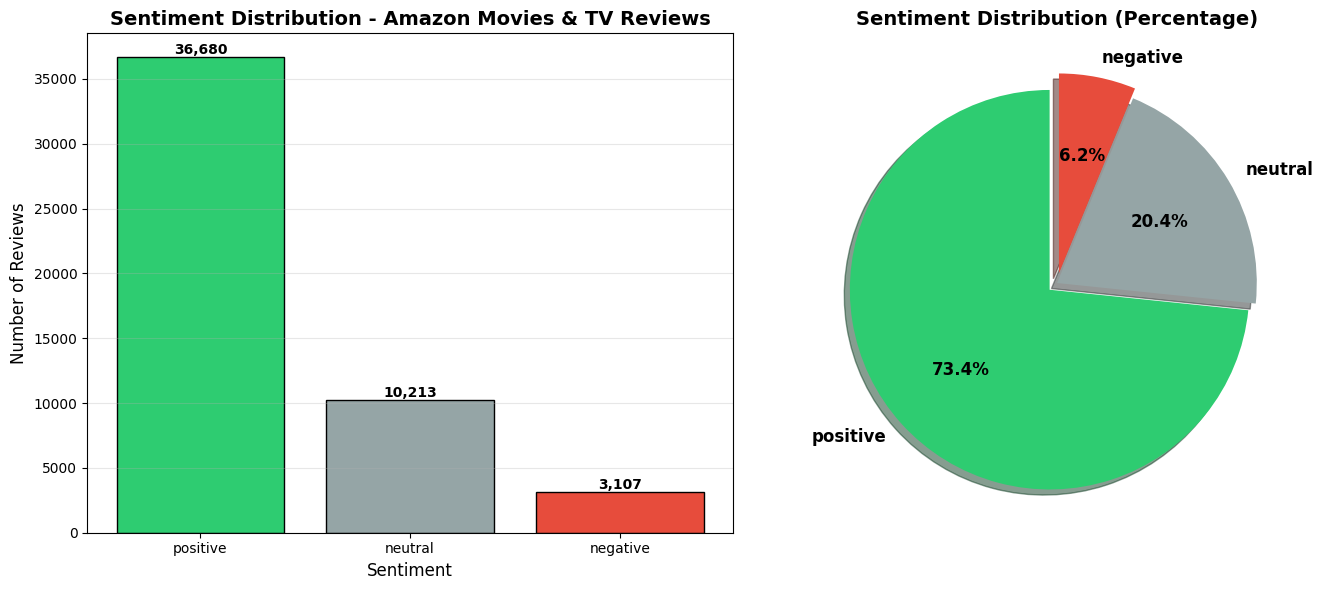

In [34]:
# Create visualization using direct method results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Use task6_results if available, otherwise use sample counts
if total_sentiment > 0:
    sentiments = list(task6_results.keys())
    counts = list(task6_results.values())
else:
    # Estimate from direct samples
    sentiments = ['positive', 'neutral', 'negative']
    counts = [len(direct_samples['positive']), len(direct_samples['neutral']), len(direct_samples['negative'])]

# Bar chart
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
bars = ax1.bar(sentiments, counts, color=colors, edgecolor='black')
ax1.set_title('Sentiment Distribution - Amazon Movies & TV Reviews', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment', fontsize=12)
ax1.set_ylabel('Number of Reviews', fontsize=12)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
             ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Pie chart
if sum(counts) > 0:
    explode = (0.05, 0, 0.05)
    ax2.pie(counts, explode=explode, labels=sentiments, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
    ax2.set_title('Sentiment Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()